In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\sunil\Downloads\Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', '0')
df['TotalCharges'] = df['TotalCharges'].astype('float')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.isnull().sum().sum() # to check overall sum of all null values

0

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df['customerID'].duplicated().sum()

0

In [9]:
def convt(value):
    if value == 1:
        return "Yes"
    else:
        return "No"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(convt)

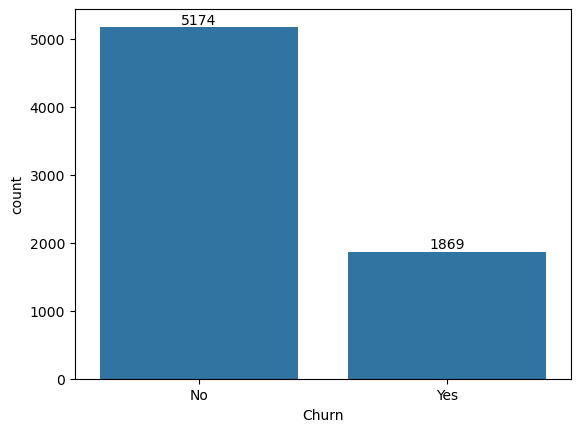

In [10]:
ax = sns.countplot(x = 'Churn', data=df)

ax.bar_label(ax.containers[0])
plt.show()

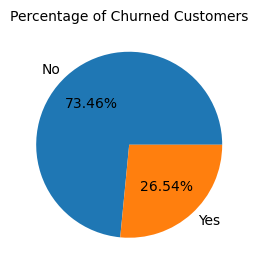

In [11]:
plt.figure(figsize = (3,4))
gb = df.groupby('Churn').agg({'Churn': 'count'})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title('Percentage of Churned Customers', fontsize = 10)
plt.show()

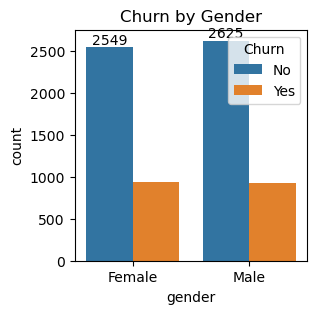

In [12]:
plt.figure(figsize=(3,3))
ax = sns.countplot(x ='gender', data= df, hue = 'Churn')

ax.bar_label(ax.containers[0])
plt.title('Churn by Gender')
plt.show()

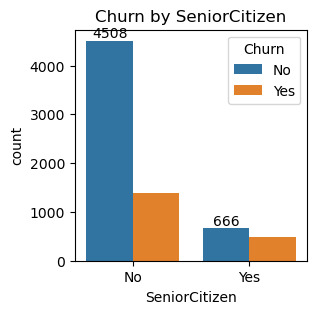

In [13]:
plt.figure(figsize=(3,3))
ax = sns.countplot(x ='SeniorCitizen', data= df, hue = 'Churn')

ax.bar_label(ax.containers[0])
plt.title('Churn by SeniorCitizen')
plt.show()

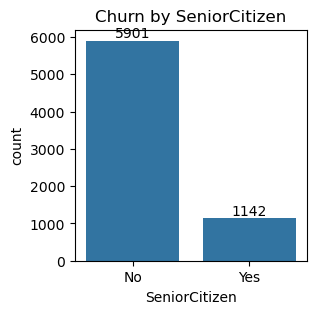

In [16]:
plt.figure(figsize=(3,3))
ax = sns.countplot(x ='SeniorCitizen', data=df)

ax.bar_label(ax.containers[0])
plt.title('Churn by SeniorCitizen')
plt.show()

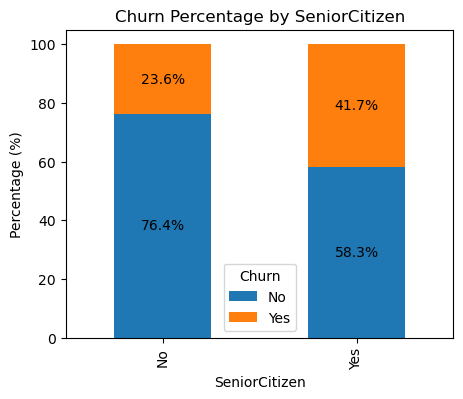

In [15]:
# Step 1: Calculate percentage table
pct_table = (
    df.groupby('SeniorCitizen')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .unstack()
)

# Step 2: Plot stacked bar chart
ax = pct_table.plot(
    kind='bar',
    stacked=True,
    figsize=(5,4)
)

# Step 3: Add percentage labels inside bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

# Step 4: Titles and labels
plt.ylabel('Percentage (%)')
plt.title('Churn Percentage by SeniorCitizen')
plt.legend(title='Churn')
plt.show()

#comparative a greater percentage of people in senior citizon category have churned

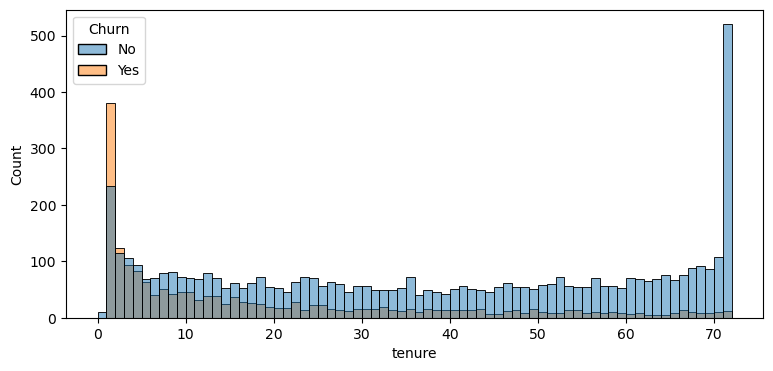

In [19]:
plt.figure(figsize = (9, 4))
sns.histplot(x= "tenure", data = df, bins = 72, hue='Churn')
plt.show()

#people who have used our servies for  long time have stayed and people who have used our serives # 1 or 2 months have churned 

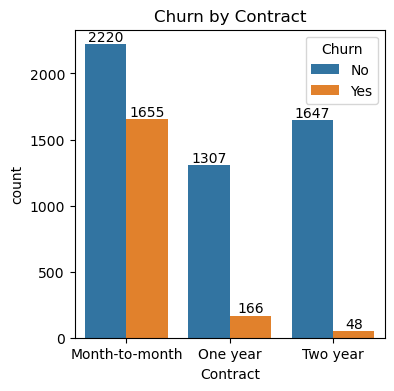

In [40]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x ='Contract', data=df, hue='Churn')

ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn by Contract')
plt.show()

#people who have month to month contract are likely to churn then from those who have 1 or 2 years of contract

In [24]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

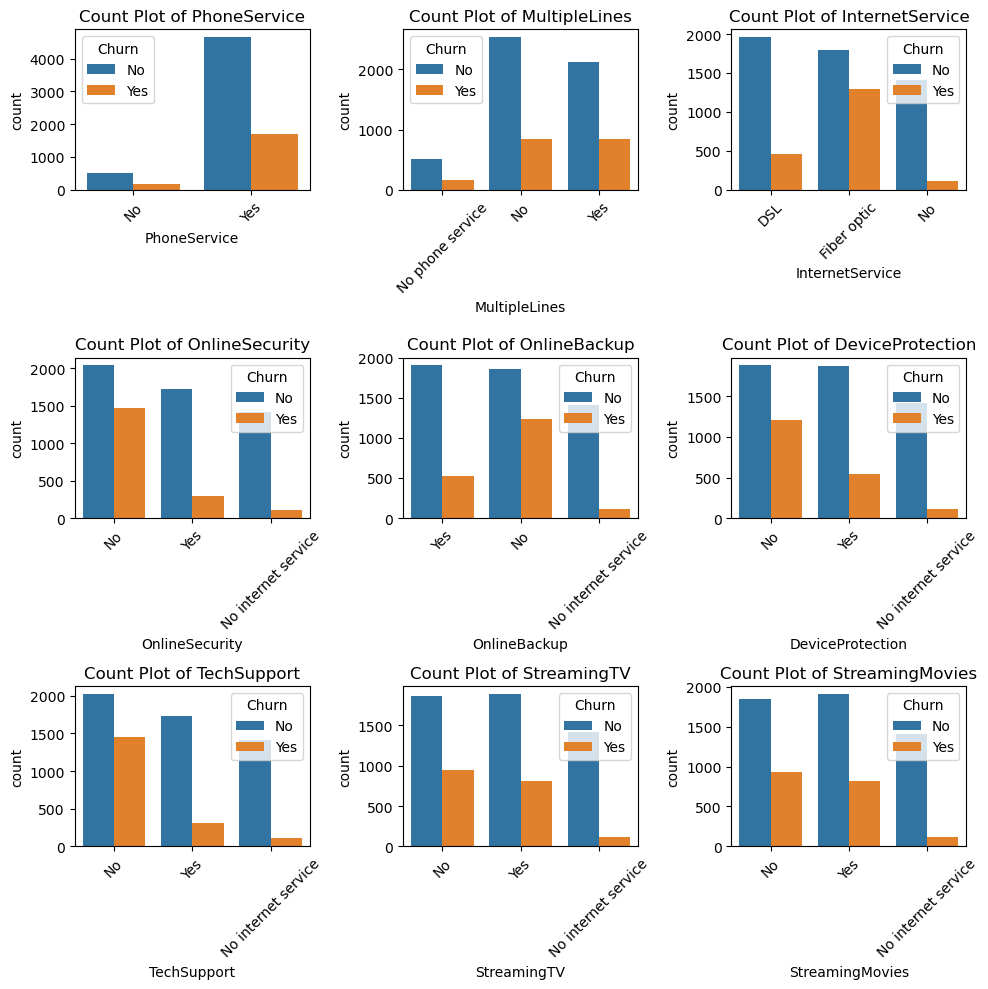

In [35]:
cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Create subplot grid
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

# Loop through columns
for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue= df['Churn'])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#Customers with PhoneService and MultipleLines = Yes have higher overall counts, but churn is still lower than non-churn in most categories.
#For InternetService, churn is noticeably higher among Fiber optic users compared to DSL and No Internet.
#For services like OnlineSecurity, OnlineBackup, and DeviceProtection, customers without these services tend to churn more.
#Overall, lack of add-on services + fiber internet users show higher churn tendency.

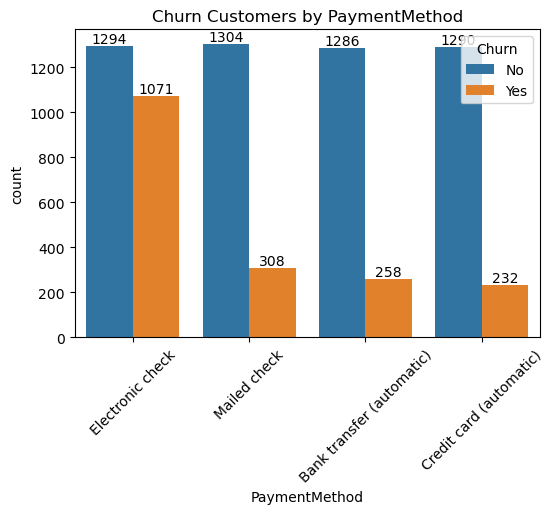

In [39]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x ='PaymentMethod', data=df, hue='Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churn Customers by PaymentMethod')
plt.xticks(rotation= 45)
plt.show()

#customer is likely to churn when he is using electronic check as a payment method